In [6]:
import numpy as np
import open3d as o3d
import os
import torch
from glob import glob

data_paths = sorted(glob('/home/yasin/Downloads/road/semantickitti_small/sequences/*/velodyne/*.bin'))
label_paths = sorted(glob('/home/yasin/Downloads/road/semantickitti_small/sequences/*/labels/*.label'))
# Define paths
data_path = "/home/yasin/Downloads/road/semantickitti_small/sequences/00/velodyne/000390.bin"  # Example path to LiDAR data
label_path = "/home/yasin/Downloads/road/semantickitti_small/sequences/00/labels/000390.label"  # Example path to label file

index = 3
data_path = data_paths[index]
label_path = label_paths[index]

# SemanticKITTI color map for each label (20 classes in SemanticKITTI)
# Color each class with RGB values for visualization
sem2sem = {
    0 : 0,     # "unlabeled"
    1 : 0,     # "outlier" mapped to "unlabeled" --------------------------mapped
    10: 1,     # "car"
    11: 2,     # "bicycle"
    13: 5,     # "bus" mapped to "other-vehicle" --------------------------mapped
    15: 3,     # "motorcycle"
    16: 5,     # "on-rails" mapped to "other-vehicle" ---------------------mapped
    18: 4,     # "truck"
    20: 5,     # "other-vehicle"
    30: 6,     # "person"
    31: 7,     # "bicyclist"
    32: 8,     # "motorcyclist"
    40: 9,     # "road"
    44: 10,    # "parking"
    48: 11,    # "sidewalk"
    49: 12,    # "other-ground"
    50: 13,    # "building"
    51: 14,    # "fence"
    52: 0,     # "other-structure" mapped to "unlabeled" ------------------mapped
    60: 9,     # "lane-marking" to "road" ---------------------------------mapped
    70: 15,    # "vegetation"
    71: 16,    # "trunk"
    72: 17,    # "terrain"
    80: 18,    # "pole"
    81: 19,    # "traffic-sign"
    99: 0,     # "other-object" to "unlabeled" ----------------------------mapped
    252: 1,    # "moving-car" to "car" ------------------------------------mapped
    253: 7,    # "moving-bicyclist" to "bicyclist" ------------------------mapped
    254: 6,    # "moving-person" to "person" ------------------------------mapped
    255: 8,    # "moving-motorcyclist" to "motorcyclist" ------------------mapped
    256: 5,    # "moving-on-rails" mapped to "other-vehicle" --------------mapped
    257: 5,    # "moving-bus" mapped to "other-vehicle" -------------------mapped
    258: 4,    # "moving-truck" to "truck" --------------------------------mapped
    259: 5     # "moving-other-vehicle" to "other-vehicle" ----------------mapped
}

color_map = {
    0: [0, 0, 0],          # "unlabeled" - black
    1: [245, 150, 100],    # "car" - red
    2: [245, 230, 100],    # "bicycle" - yellow
    3: [250, 80, 100],     # "motorcycle" - pink
    4: [150, 60, 30],      # "truck" - brown
    5: [180, 30, 80],      # "other-vehicle" - dark red
    6: [255, 0, 0],        # "person" - bright red
    7: [30, 30, 255],      # "bicyclist" - blue
    8: [200, 40, 255],     # "motorcyclist" - purple
    9: [90, 30, 150],      # "road" - dark purple
    10: [255, 0, 255],     # "parking" - magenta
    11: [255, 150, 255],   # "sidewalk" - light pink
    12: [75, 0, 75],       # "other-ground" - dark purple
    13: [75, 0, 175],      # "building" - dark blue
    14: [0, 200, 255],     # "fence" - sky blue
    15: [50, 120, 255],    # "vegetation" - greenish blue
    16: [0, 175, 0],       # "trunk" - green
    17: [0, 60, 135],      # "terrain" - dark cyan
    18: [80, 240, 150],    # "pole" - light green
    19: [150, 240, 255],   # "traffic-sign" - light cyan
    20: [150, 240, 0],   # "traffic-sign" - light cyan
    21: [150, 0, 255],   # "traffic-sign" - light cyan
    22: [0, 240, 255]   # "traffic-sign" - light cyan
}


color_map = torch.tensor(list(color_map.values()))

# Create lookup tensor for class mapping
mapdict = sem2sem
max_index = max(mapdict.keys())
lookup_tensor = torch.zeros(max_index + 1, dtype=torch.long)
for old_idx, new_idx in mapdict.items():
    lookup_tensor[old_idx] = new_idx

# Load point cloud and label data
def load_point_cloud(file_path):
    """Load point cloud from a .bin file."""
    point_cloud = np.fromfile(file_path, dtype=np.float32).reshape(-1, 4)
    return point_cloud

def load_labels(label_path):
    """Load labels from a .label file."""
    labels = np.fromfile(label_path, dtype=np.int32) & 0xFFFF
    labels = lookup_tensor[labels]
    return labels.numpy()

def colorize_point_cloud(points, labels, color_map):
    """Apply colors to point cloud based on labels and a predefined color map."""
    colors = np.array([color_map[label] for label in labels]) / 255.0
    return colors

# Load data
points_all = load_point_cloud(data_path)
points = points_all[:, :3]  # Only XYZ, ignore intensity
labels = load_labels(label_path)
colors = colorize_point_cloud(points, labels, color_map)

# Create Open3D point cloud object and set points and colors
pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(points)
pcd.colors = o3d.utility.Vector3dVector(colors)

# Add coordinate frame for visualization of the coordinate system
coordinate_frame = o3d.geometry.TriangleMesh.create_coordinate_frame(size=2.0, origin=[0, 0, 0])

# Visualize the point cloud with the coordinate frame
o3d.visualization.draw_geometries([pcd, coordinate_frame], window_name="SemanticKITTI Point Cloud", width=800, height=600)

In [2]:
labelmask = labels==9
pointmask1 = (points[...,0]<5)*(points[...,0]>-5)
pointmask2 = points[...,1]<5
pointmask3 = points[...,1]>-5
pointmask4 = points[...,2]>-5
pointmask5 = points[...,2]<5
pointmask = pointmask1*pointmask2*pointmask3*pointmask4*pointmask5
allmask = pointmask*labelmask

points = points[allmask]
labels = labels[allmask]

In [3]:
colors = colorize_point_cloud(points, labels, color_map)

# Create Open3D point cloud object and set points and colors
pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(points)
pcd.colors = o3d.utility.Vector3dVector(colors)

# Add coordinate frame for visualization of the coordinate system
coordinate_frame = o3d.geometry.TriangleMesh.create_coordinate_frame(size=2.0, origin=[0, 0, 0])

# Visualize the point cloud with the coordinate frame
o3d.visualization.draw_geometries([pcd, coordinate_frame], window_name="SemanticKITTI Point Cloud", width=800, height=600)

In [4]:
points[...,2].mean()

-1.7493186

In [7]:
from glob import glob
wifiles = sorted(glob('/home/yasin/Downloads/road/waymodataset/training/images/*'))
wlfiles = sorted(glob('/home/yasin/Downloads/road/waymodataset/training/labels/*'))

root = '/home/yasin/Downloads/road/waymodataset/training'
calibroot = '/home/yasin/Downloads/road/waymodataset/training/calibs'
images = sorted(glob(f'{root}/images/*.npz'))
labels = sorted(glob(f'{root}/labels/*.npz'))
calibs = sorted(glob(f'{calibroot}/*.csv'))
image_to_calibration = dict()
for image_file in images:
    for calibration_file in calibs:
        prefix = calibration_file.split('.')[0].split('/')[-1]
        if image_file.split('/')[-1].startswith(prefix):
            image_to_calibration[image_file] = calibration_file
            break

wcfiles = [image_to_calibration[i] for i in wifiles]

In [8]:
def transform_point_cloud(point_cloud, transformation_matrix):
    """
    Transforms a point cloud using a given 4x4 transformation matrix.

    Parameters:
    - point_cloud (numpy.ndarray): An Nx3 array representing the point cloud.
    - transformation_matrix (numpy.ndarray): A 4x4 transformation matrix.

    Returns:
    - numpy.ndarray: The transformed Nx3 point cloud.
    """
    if transformation_matrix.shape != (4, 4):
        raise ValueError("Transformation matrix must be 4x4.")
    if point_cloud.shape[1] != 3:
        raise ValueError("Point cloud must have shape Nx3.")

    # Add homogeneous coordinate
    ones = np.ones((point_cloud.shape[0], 1))
    point_cloud_homogeneous = np.hstack([point_cloud, ones])  # Shape: N,4

    # Apply transformation
    transformed_homogeneous = point_cloud_homogeneous @ transformation_matrix.T  # Shape: N,4

    # Extract transformed coordinates
    transformed_point_cloud = transformed_homogeneous[:, :3]  # Shape: N,3
    
    return transformed_point_cloud

flat_matrix = [
    -8.50125289e-01, -5.26574882e-01,  2.42619623e-03,  1.43000000e+00,
     5.26578914e-01, -8.50124957e-01,  1.48508379e-03,  0.00000000e+00,
     1.28056215e-03,  2.54009106e-03,  9.99995954e-01,  2.18400000e+00,
     0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  1.00000000e+00
]
transformation_matrix = np.array(flat_matrix).reshape(4, 4)


def reverse_transform_point_cloud(transformed_point_cloud,index):
    """
    Reverts a transformed point cloud to its original using the inverse of the transformation matrix.

    Parameters:
    - transformed_point_cloud (numpy.ndarray): An Nx3 array representing the transformed point cloud.
    - transformation_matrix (numpy.ndarray): A 4x4 transformation matrix.

    Returns:
    - numpy.ndarray: The original Nx3 point cloud.
    """

    
    df = pd.read_csv(wcfiles[index])
    arstr = df[keytr].values[0]
    array = np.fromstring(arstr.strip('[]'), sep=' ')
    transformation_matrix = np.array(array).reshape(4, 4)

    # Compute the inverse of the transformation matrix
    inverse_matrix = np.linalg.inv(transformation_matrix)

    # Add homogeneous coordinate to the transformed point cloud
    ones = np.ones((transformed_point_cloud.shape[0], 1))
    transformed_homogeneous = np.hstack([transformed_point_cloud, ones])  # Shape: N,4

    # Apply the inverse transformation
    original_homogeneous = transformed_homogeneous @ inverse_matrix.T  # Shape: N,4

    # Extract the original coordinates
    original_point_cloud = original_homogeneous[:, :3]  # Shape: N,3
    print(original_homogeneous[:, 3:])

    return original_point_cloud

In [51]:
# Load data
index = 25
sx = 1.43
sz = 2.184
sy = 0
s = np.array([sx,sy,sz])
waymo_points_all = np.load(wifiles[index])['array'].astype(np.float32)
waymo_points = waymo_points_all[1:4,...]
waymo_points[1:3] = -1*waymo_points[1:3] 
waymo_points[0] = waymo_points[0]-sx
waymo_points[2] = waymo_points[2]+sz
waymo_points[1] = -1*waymo_points[1]
waymo_points[2] = waymo_points[2]-1
waymo_points = np.transpose(waymo_points,(1,2,0)).reshape(-1,3)

#waymo_points = reverse_transform_point_cloud(waymo_points, index)

waymo_labels = np.load(wlfiles[index])['array'].reshape(-1)
#waymo_points = waymo_points[ (waymo_labels == 18)]
#waymo_labels = waymo_labels[(waymo_labels == 18)]
waymo_colors = colorize_point_cloud(waymo_points, waymo_labels, color_map)


# Create Open3D point cloud object and set points and colors
pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(waymo_points)
pcd.colors = o3d.utility.Vector3dVector(waymo_colors)

# Add coordinate frame for visualization of the coordinate system
coordinate_frame = o3d.geometry.TriangleMesh.create_coordinate_frame(size=2.0, origin=[0, 0, 0])

# Visualize the point cloud with the coordinate frame
o3d.visualization.draw_geometries([pcd, coordinate_frame], window_name="SemanticKITTI Point Cloud", width=800, height=600)

In [26]:
import pandas as pd
keytr = '[LiDARCalibrationComponent].extrinsic.transform'
keyinc = '[LiDARCalibrationComponent].beam_inclination.values'

In [27]:
df = pd.read_csv(wcfiles[0])
arstr = df[keytr].values[0]
array = np.fromstring(arstr.strip('[]'), sep=' ')

In [28]:
df.head()

,Unnamed: 0,key.segment_context_name,key.laser_name,[LiDARCalibrationComponent].extrinsic.transform,[LiDARCalibrationComponent].beam_inclination.min,[LiDARCalibrationComponent].beam_inclination.max,[LiDARCalibrationComponent].beam_inclination.values
0,4,10498013744573185290_1240_000_1260_000,1,[-8.44203957e-01 -5.36017924e-01 2.11306781e-...,-0.313889,0.040506,[-0.30860236 -0.29802864 -0.28746247 -0.277183...


In [29]:
s = list(set(wcfiles))

In [30]:
for index in range(len(s)):
    df = pd.read_csv(s[index])
    arstr = df[keytr].values[0]
    array = np.fromstring(arstr.strip('[]'), sep=' ')
    print(array)

[-8.50125289e-01 -5.26574882e-01  2.42619623e-03  1.43000000e+00
  5.26578914e-01 -8.50124957e-01  1.48508379e-03  0.00000000e+00
  1.28056215e-03  2.54009106e-03  9.99995954e-01  2.18400000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]
[-8.52987597e-01 -5.21931082e-01 -3.23820463e-04  1.43000000e+00
  5.21931064e-01 -8.52987657e-01  1.42383563e-04  0.00000000e+00
 -3.50529265e-04 -4.75605460e-05  9.99999937e-01  2.18400000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]
[-8.50125289e-01 -5.26574882e-01  2.42619623e-03  1.43000000e+00
  5.26578914e-01 -8.50124957e-01  1.48508379e-03  0.00000000e+00
  1.28056215e-03  2.54009106e-03  9.99995954e-01  2.18400000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]
[-8.57439543e-01 -5.14576377e-01  2.92971384e-03  1.43000000e+00
  5.14583171e-01 -8.57409118e-01  7.33236064e-03  0.00000000e+00
 -1.26109621e-03  7.79463739e-03  9.99968826e-01  2.18400000e+00
  0.00000000e+00  0.00

In [31]:
df.head()

,Unnamed: 0,key.segment_context_name,key.laser_name,[LiDARCalibrationComponent].extrinsic.transform,[LiDARCalibrationComponent].beam_inclination.min,[LiDARCalibrationComponent].beam_inclination.max,[LiDARCalibrationComponent].beam_inclination.values
0,4,1382515516588059826_780_000_800_000,1,[-8.50125289e-01 -5.26574882e-01 2.42619623e-...,-0.314901,0.039964,[-0.30963164 -0.29909352 -0.28858046 -0.278095...


In [32]:
def range_image_to_point_cloud_with_labels(range_image, inclination_angles, labels):
    """
    Converts a range image to a point cloud and includes corresponding labels.

    Parameters:
    - range_image: A 2D numpy array of shape (64, 2650), representing the range values for each pixel.
    - inclination_angles: A 1D numpy array of shape (64,), representing the inclination angle for each row.
    - labels: A 2D numpy array of shape (64, 2650), representing the label for each pixel.

    Returns:
    - point_cloud: A 2D numpy array of shape (64 * 2650, 3) containing the (x, y, z) coordinates of the point cloud.
    - point_labels: A 1D numpy array of shape (64 * 2650,) containing the labels associated with each point.
    """

    # Create a meshgrid for azimuth angles for each pixel column
    azimuth_angles = np.linspace(-np.pi, np.pi, range_image.shape[1])

    # Repeat the inclination and azimuth angles to match the range image shape
    inclination = np.repeat(inclination_angles[:, np.newaxis], range_image.shape[1], axis=1)
    azimuth = np.tile(azimuth_angles, (range_image.shape[0], 1))

    # Calculate the Cartesian coordinates
    x = range_image * np.cos(inclination) * np.cos(azimuth)
    y = range_image * np.cos(inclination) * np.sin(azimuth)
    z = range_image * np.sin(inclination)

    # Stack the x, y, z coordinates to form the point cloud
    point_cloud = np.stack((x, y, z), axis=-1).reshape(-1, 3)

    # Flatten the labels array to match the shape of the point cloud
    point_labels = labels.flatten()

    return point_cloud, point_labels

def get_inc(filename):
    df = pd.read_csv(filename)
    arstr = df[keyinc].values[0]
    array = np.fromstring(arstr.strip('[]'), sep=' ')
    return array

In [33]:
index = 200
rng = np.load(wifiles[index])['array'].astype(np.float32)[0]
lbl = np.load(wlfiles[index])['array']
clb = get_inc(wcfiles[index])
point_cloud, point_labels = range_image_to_point_cloud_with_labels(rng, clb, lbl)

In [34]:
clb = get_inc(wcfiles[index])
point_cloud, point_labels = range_image_to_point_cloud_with_labels(rng, clb, lbl)

In [35]:
df = pd.read_csv(wcfiles[0])
arstr = df[keyinc].values[0]
array = np.fromstring(arstr.strip('[]'), sep=' ')
mm = np.array([-0.313889,	0.040506])

In [36]:
step = (0.313889+0.040506)/63.0
newinc = [i*step+-0.313889 for i in range(64)]
newinc = np.array(newinc)

In [37]:
waymo_points = point_cloud
waymo_labels = point_labels
waymo_colors = colorize_point_cloud(waymo_points, waymo_labels, color_map)

# Create Open3D point cloud object and set points and colors
pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(waymo_points)
pcd.colors = o3d.utility.Vector3dVector(waymo_colors)

# Add coordinate frame for visualization of the coordinate system
coordinate_frame = o3d.geometry.TriangleMesh.create_coordinate_frame(size=2.0, origin=[0, 0, 0])

# Visualize the point cloud with the coordinate frame
o3d.visualization.draw_geometries([pcd, coordinate_frame], window_name="SemanticKITTI Point Cloud", width=800, height=600)

In [40]:
import math
angmin,angmax = -0.314831, 0.039103
dermin,dermax = angmin*180/math.pi, angmax*180/math.pi
print(dermin,dermax)

from glob import glob
wifiles = sorted(glob('/home/yasin/Downloads/road/waymodataset/training/images/*'))
wlfiles = sorted(glob('/home/yasin/Downloads/road/waymodataset/training/labels/*'))

from laserscan import SemLaserScanWaymo
scan = SemLaserScanWaymo(sem_color_dict=None, project=False, H=64, W=2650, fov_up=2.25, fov_down=-18.1, 
    max_classes=24,DA=False,flip_sign=False,drop_points=False)

index = 0
scan.open_scan(wifiles[index])
scan.open_label(wlfiles[index])

-18.038487559883222 2.240436866300058


In [41]:
import sys
sys.path.append('/home/yasin/sil/SalsaNext/train/tasks/semantic/dataset/kitti')
sys.path.append('/home/yasin/sil/SalsaNext/train')
from parser import SemanticKitti
from mappings import kitti, kitticolormap,sem2sem, kitti_lm_inv,waymocolormap,waymo
sensor={
    'name': "HDL64",
    'type': "spherical" ,
    'fov_up': 3,
    'fov_down': -25,
    'img_prop': {
      'width': 2048,
      'height': 64},
    'img_means':[ #range,x,y,z,signal
       0,
       0,
       0,
       0,
       0],
    'img_stds':[ #range,x,y,z,signal
       1,
       1,
       1,
       1,
       1]
}

Sequences folder exists! Using sequences from /home/yasin/Downloads/road/semantickitti_small/sequences
parsing seq 00
parsing seq 01
parsing seq 02
parsing seq 03
Using 64 scans from sequences [0, 1, 2, 3]


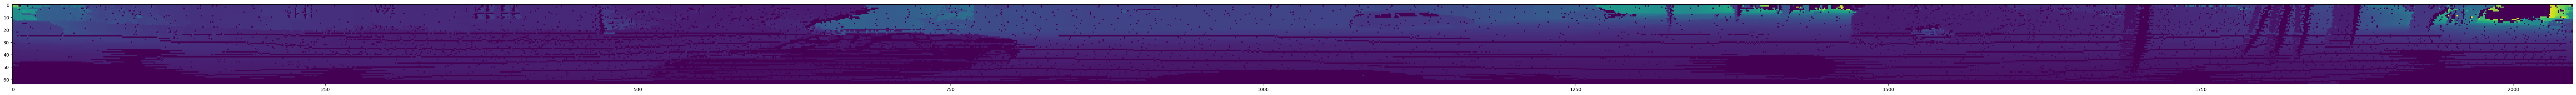

tensor(2.7224)


In [42]:
root = '/home/yasin/Downloads/bestwaymo/waymodataset'
root = '/home/yasin/Downloads/road/semantickitti_small'
sequences = [0,1,2,3]
labels = kitti
color_map = kitticolormap
learning_map = sem2sem
learning_map_inv = kitti_lm_inv
sensor = sensor 
max_points=150000
gt=True
transform=False
iswaymo = False
istrain = False
ds = SemanticKitti(root,    # directory where data is
               sequences,     # sequences for this data (e.g. [1,3,4,6])
               labels,        # label dict: (e.g 10: "car")
               color_map,     # colors dict bgr (e.g 10: [255, 0, 0])
               learning_map,  # classes to learn (0 to N-1 for xentropy)
               learning_map_inv,    # inverse of previous (recover labels)
               sensor,              # sensor to parse scans from
               max_points=150000,   # max number of points present in dataset
               gt=True,             # send ground truth?
               transform=False,
               iswaymo = False,
               istrain = False)

b = ds[10]
import matplotlib.pyplot as plt
plt.figure(figsize=(100, 25))
plt.imshow(b[0][0][...,:])
plt.show()
rim = b[0][0]
print((rim!=0).sum()/(rim==0).sum())

Sequences folder exists! Using sequences from /home/yasin/Downloads/bestwaymo/waymodataset/training
Using 300 scans from sequences [0, 1, 2, 3]
tensor(1.4656)


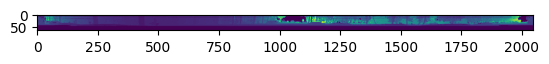

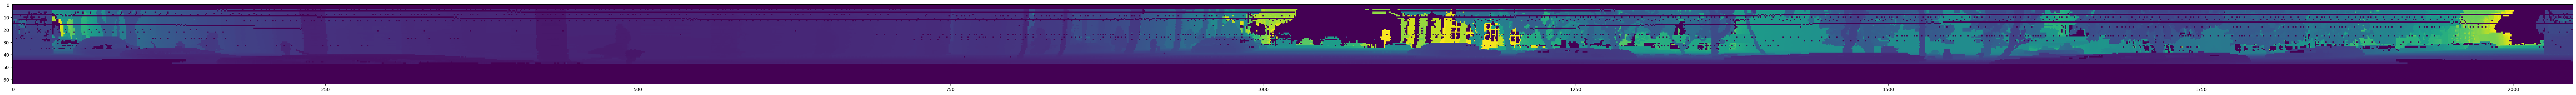

In [87]:
root = '/home/yasin/Downloads/bestwaymo/waymodataset'
sequences = [0,1,2,3]
labels = waymo
color_map = waymocolormap
learning_map = {i:i for i in range(23)}
learning_map_inv = {i:i for i in range(23)}
sensor = sensor 
max_points=160000
gt=True
transform=False
iswaymo = True
istrain = True
sensor={
    'name': "HDL64",
    'type': "spherical" ,
    'fov_up': 20,
    'fov_down': -10,
    'img_prop': {
      'width': 2048,
      'height': 64},
    'img_means':[ #range,x,y,z,signal
       0,
       0,
       0,
       0,
       0],
    'img_stds':[ #range,x,y,z,signal
       1,
       1,
       1,
       1,
       1]
}
ds = SemanticKitti(root,    # directory where data is
               sequences,     # sequences for this data (e.g. [1,3,4,6])
               labels,        # label dict: (e.g 10: "car")
               color_map,     # colors dict bgr (e.g 10: [255, 0, 0])
               learning_map,  # classes to learn (0 to N-1 for xentropy)
               learning_map_inv,    # inverse of previous (recover labels)
               sensor,              # sensor to parse scans from
               max_points=max_points,   # max number of points present in dataset
               gt=gt,             # send ground truth?
               transform=True,
               iswaymo = iswaymo,
               istrain = istrain)

b = next(iter(ds))
import matplotlib.pyplot as plt
plt.imshow(b[0][0][...,0:2650])
rim = b[0][0]
print((rim!=0).sum()/(rim==0).sum())
plt.figure(figsize=(100, 25))

# Display the image
plt.imshow(b[0][0][...,:])

# Show the plot
plt.show()

In [86]:
64*24650

1577600

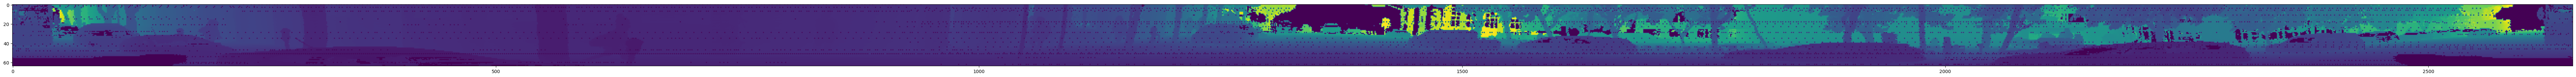

In [78]:
import numpy as np
ar = np.load(ds.scan_files[0])['array']
plt.figure(figsize=(100, 25))
plt.imshow(ar[0][...,:])
plt.show()

In [51]:
pts = b[0].permute((1,2,0))[...,1:4].reshape(-1,3)
mask = b[0][0].reshape(-1) != 0
lbl = b[2].reshape(-1)[mask]
pts = pts[mask]

In [59]:
waymo_points = pts
waymo_labels = lbl
waymo_colors = colorize_point_cloud(waymo_points.numpy(), waymo_labels.numpy(), color_map)

# Create Open3D point cloud object and set points and colors
pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(waymo_points)
pcd.colors = o3d.utility.Vector3dVector(waymo_colors)

# Add coordinate frame for visualization of the coordinate system
coordinate_frame = o3d.geometry.TriangleMesh.create_coordinate_frame(size=2.0, origin=[0, 0, 0])

# Visualize the point cloud with the coordinate frame
o3d.visualization.draw_geometries([pcd, coordinate_frame], window_name="SemanticKITTI Point Cloud", width=800, height=600)

In [55]:
lbl.min()

tensor(0, dtype=torch.int32)

In [58]:
waymocolormap

{0: [0, 0, 0],
 1: [0, 0, 255],
 2: [245, 150, 100],
 3: [245, 230, 100],
 4: [250, 80, 100],
 5: [150, 60, 30],
 6: [255, 0, 0],
 7: [180, 30, 80],
 8: [255, 0, 0],
 9: [30, 30, 255],
 10: [200, 40, 255],
 11: [90, 30, 150],
 12: [255, 0, 255],
 13: [255, 150, 255],
 14: [75, 0, 75],
 15: [75, 0, 175],
 16: [0, 200, 255],
 17: [50, 120, 255],
 18: [0, 150, 255],
 19: [170, 255, 150],
 20: [0, 175, 0],
 21: [0, 60, 135],
 22: [80, 240, 150]}